In [1]:
import os
import anndata as ad
import numpy as np
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import omicverse as ov
import scvi
from scvi.model.utils import mde

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.5.3, Tutorials: https://omicverse.readthedocs.io/


[rank: 0] Global seed set to 0


In [2]:
sc.settings.set_figure_params(dpi=100, frameon=False)
sc.set_figure_params(dpi=100)
sc.set_figure_params(figsize=(3, 3))
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (3, 3)


In [3]:
# Change the working directory to the Garfield folder (if needed)
os.chdir('/storage2/liuxiaodongLab/fanxueying/embryo_benchmarking_rebuttal/code/20250725_cross-species_integration_v3')
os.getcwd()

'/storage2/liuxiaodongLab/fanxueying/embryo_benchmarking_rebuttal/code/20250725_cross-species_integration_v3'

In [4]:
# Load dataset
human = sc.read('/storage2/liuxiaodongLab/fanxueying/embryo_benchmarking_rebuttal/data/human_clustering_20250724_v3.h5ad')
human

AnnData object with n_obs × n_vars = 33794 × 60428
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'orig_anno', 'orig_sub_anno', 'harmo.anno', 'doublet', 'doublet_score', 'scANVI_res_0.5', 'leiden_3', 'reanno', 'combined_annotation', 'unicorns', 'lineage'
    var: 'features', 'n_cells', 'highly_variable'
    uns: 'dendrogram_reanno', 'harmo.anno_colors', 'hvg', 'leiden', 'leiden_3_colors', 'lineage_colors', 'log1p', 'neighbors', 'orig.ident_colors', 'orig_sub_anno_colors', 'pca', 'rank_genes_groups', 'reanno_colors', 'scANVI_res_0.5_colors', 'stage_colors', 'umap', 'unicorns_colors'
    obsm: 'X_pca', 'X_scANVI', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

In [5]:
# Load dataset
monkey = sc.read('/storage2/liuxiaodongLab/fanxueying/embryo_benchmarking_rebuttal/data/monkey_reanno_20250706.h5ad')
monkey

AnnData object with n_obs × n_vars = 142570 × 44223
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'orig_anno', 'orig_sub_anno', 'harmo.anno', 'doublet', 'doublet_score', 'scANVI_res_0.5', 'leiden_3', 'reanno', 'lineage'
    var: 'features', 'n_cells', 'highly_variable'
    uns: 'harmo.anno_colors', 'hvg', 'leiden', 'leiden_3_colors', 'lineage_colors', 'log1p', 'neighbors', 'orig.ident_colors', 'pca', 'reanno_colors', 'scANVI_res_0.5_colors', 'stage_colors', 'umap'
    obsm: 'X_pca', 'X_scANVI', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

In [6]:
set(human.obs["lineage"])

{'Amniotic_ecto',
 'Endoderm',
 'ExE_endo',
 'NMP',
 'Notochord',
 'PGC',
 'Primitive.streak',
 'TE_TrB',
 'epi',
 'hemogenic',
 'meso_Exe.meso',
 'neural_ecto'}

In [7]:
set(monkey.obs["lineage"])

{'Amniotic_ecto',
 'Endoderm',
 'ExE_endo',
 'NMP',
 'Notochord',
 'PGC',
 'Primitive.streak',
 'TE_TrB',
 'epi',
 'hemogenic',
 'meso_Exe.meso',
 'neural_ecto'}

In [8]:
adata_combined = sc.concat([human, monkey], join='outer', axis=0)

In [9]:
adata_combined

AnnData object with n_obs × n_vars = 176364 × 86375
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'orig_anno', 'orig_sub_anno', 'harmo.anno', 'doublet', 'doublet_score', 'scANVI_res_0.5', 'leiden_3', 'reanno', 'combined_annotation', 'unicorns', 'lineage'
    obsm: 'X_pca', 'X_scANVI', 'X_umap'
    layers: 'counts', 'logcounts'

In [10]:
del human, monkey    #free space

In [11]:
# remove "empty" genes
sc.pp.filter_genes(adata_combined, min_cells=1)

In [12]:
adata_combined

AnnData object with n_obs × n_vars = 176364 × 85305
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'orig_anno', 'orig_sub_anno', 'harmo.anno', 'doublet', 'doublet_score', 'scANVI_res_0.5', 'leiden_3', 'reanno', 'combined_annotation', 'unicorns', 'lineage'
    var: 'n_cells'
    obsm: 'X_pca', 'X_scANVI', 'X_umap'
    layers: 'counts', 'logcounts'

In [13]:
adata_combined.X = adata_combined.layers["counts"].copy()

In [14]:
sc.settings.seed = 42
sc.pp.normalize_total(adata_combined, target_sum=1e4)
sc.pp.log1p(adata_combined)
adata_combined.layers["logcounts"] = adata_combined.X.copy()
sc.pp.highly_variable_genes(adata_combined, n_top_genes=2000, flavor="cell_ranger", batch_key="orig.ident")
sc.tl.pca(adata_combined, n_comps=30, use_highly_variable=True)

In [15]:
adata_combined

AnnData object with n_obs × n_vars = 176364 × 85305
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'orig_anno', 'orig_sub_anno', 'harmo.anno', 'doublet', 'doublet_score', 'scANVI_res_0.5', 'leiden_3', 'reanno', 'combined_annotation', 'unicorns', 'lineage'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca', 'X_scANVI', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts'

In [16]:
adata = adata_combined.copy()

In [17]:
adata_hvg = adata[:, adata.var.highly_variable].copy()

In [18]:
adata_hvg

AnnData object with n_obs × n_vars = 176364 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'orig_anno', 'orig_sub_anno', 'harmo.anno', 'doublet', 'doublet_score', 'scANVI_res_0.5', 'leiden_3', 'reanno', 'combined_annotation', 'unicorns', 'lineage'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca', 'X_scANVI', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts'

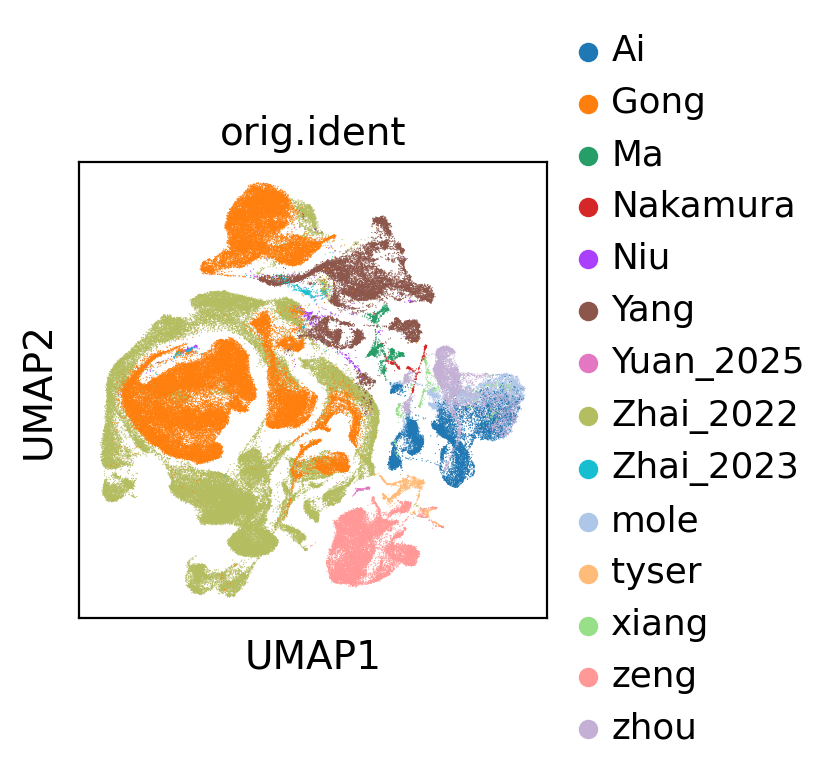

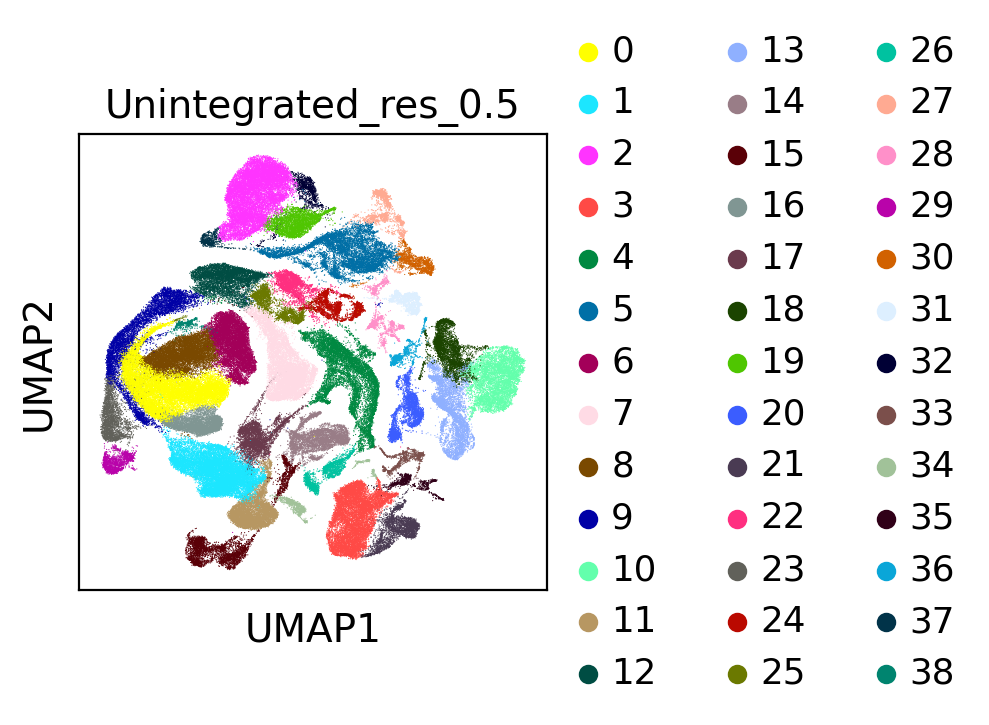

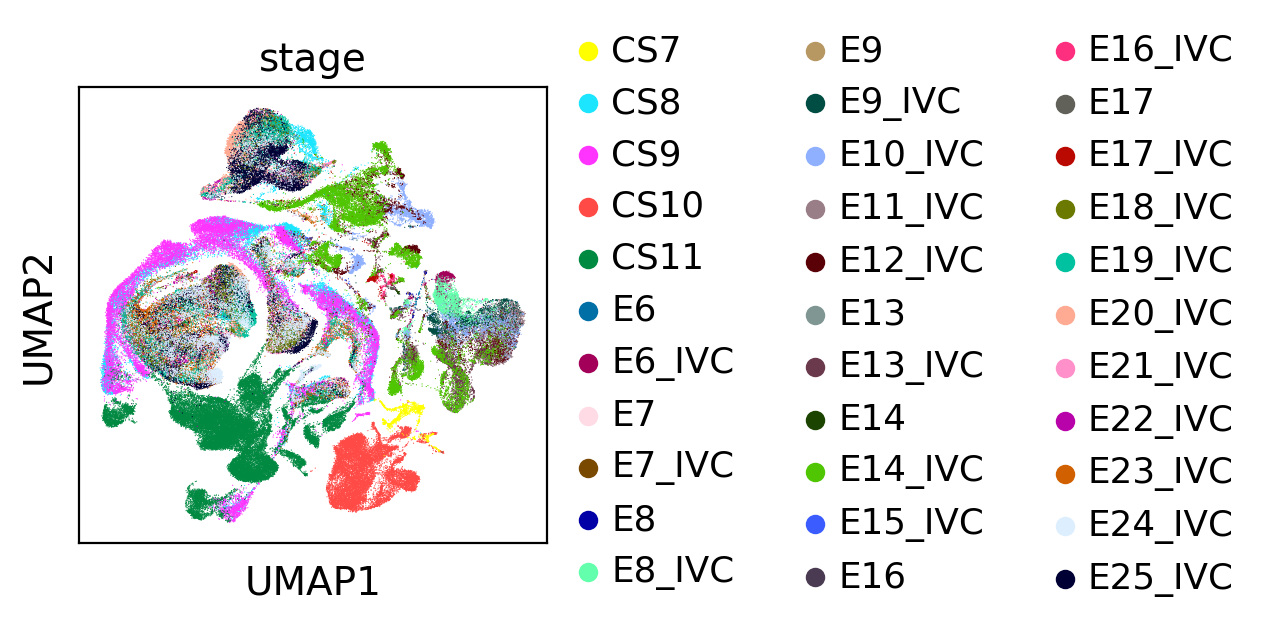

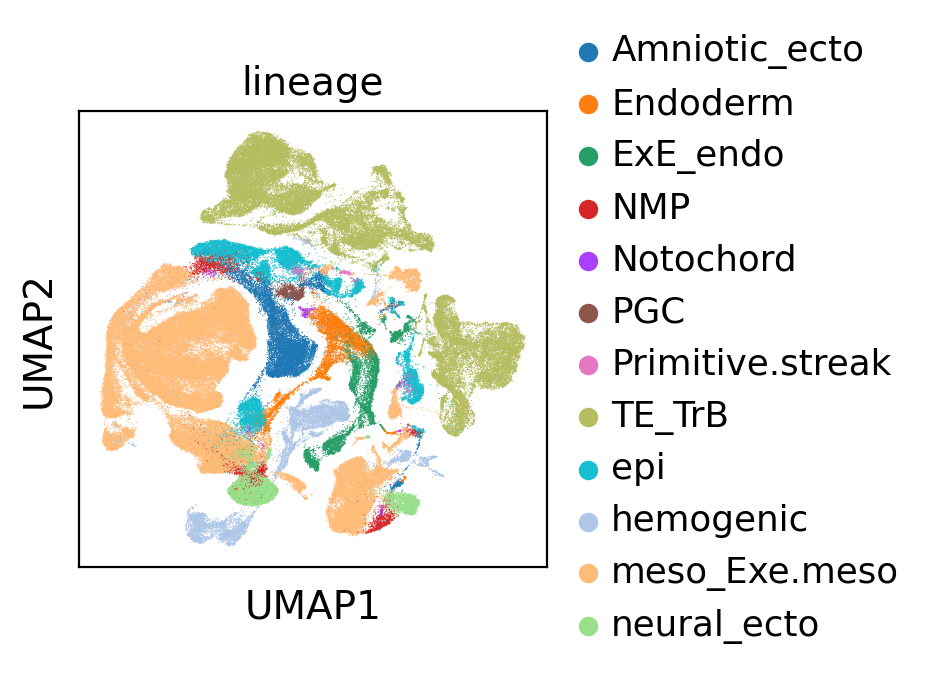

In [19]:
####Unintegrated
adata.obsm["Unintegrated"] = adata_hvg.obsm["X_pca"]
adata_hvg.obsm["Unintegrated"] = adata_hvg.obsm["X_pca"]
sc.pp.neighbors(adata, use_rep="Unintegrated",random_state=42)
sc.tl.leiden(adata, resolution=0.5,key_added=f"Unintegrated_res_0.5",random_state=42)
sc.tl.umap(adata,random_state=42)
adata.obsm['X_Unintegrated'] = adata.obsm['X_umap']
sc.pl.umap(adata, color=['orig.ident'], save="Unintegrated_orig_ident.pdf")
sc.pl.umap(adata, color=['Unintegrated_res_0.5'], save="Unintegrated_res_0.5.pdf")
sc.pl.umap(adata, color=['stage'], save="Unintegrated_stage.pdf")
sc.pl.umap(adata, color=['lineage'], save="Unintegrated_lineage.pdf")

In [20]:
###scVI
scvi.model.SCVI.setup_anndata(adata_hvg, layer="counts", batch_key="orig.ident")
vae = scvi.model.SCVI(adata_hvg, gene_likelihood="nb", n_layers=2, n_latent=30)
vae.train()
adata.obsm["scVI"] = vae.get_latent_representation()

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 45/45: 100%|██████████| 45/45 [15:23<00:00, 20.61s/it, loss=1.41e+03, v_num=1]

`Trainer.fit` stopped: `max_epochs=45` reached.


Epoch 45/45: 100%|██████████| 45/45 [15:23<00:00, 20.53s/it, loss=1.41e+03, v_num=1]


In [21]:
###scANVI
lvae = scvi.model.SCANVI.from_scvi_model(
    vae,
    adata=adata_hvg,
    labels_key="lineage",
    unlabeled_category="Unknown",
)
lvae.train(max_epochs=20, n_samples_per_label=100)
adata.obsm["scANVI"] = lvae.get_latent_representation()

INFO     Training for 20 epochs.                                                                                   


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 20/20: 100%|██████████| 20/20 [13:21<00:00, 39.18s/it, loss=1.5e+03, v_num=1] 

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 20/20: 100%|██████████| 20/20 [13:21<00:00, 40.07s/it, loss=1.5e+03, v_num=1]


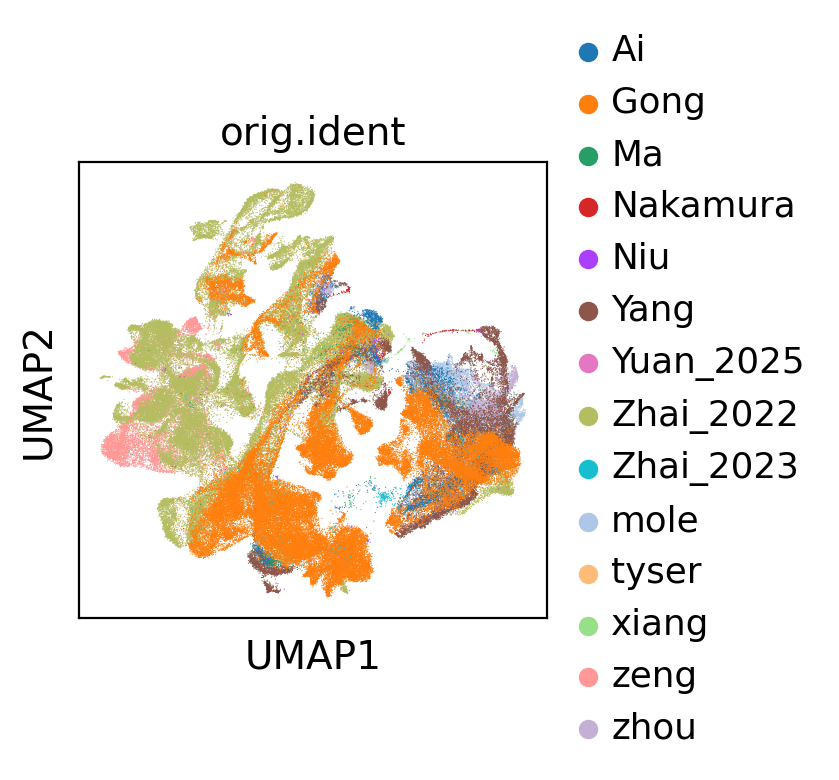

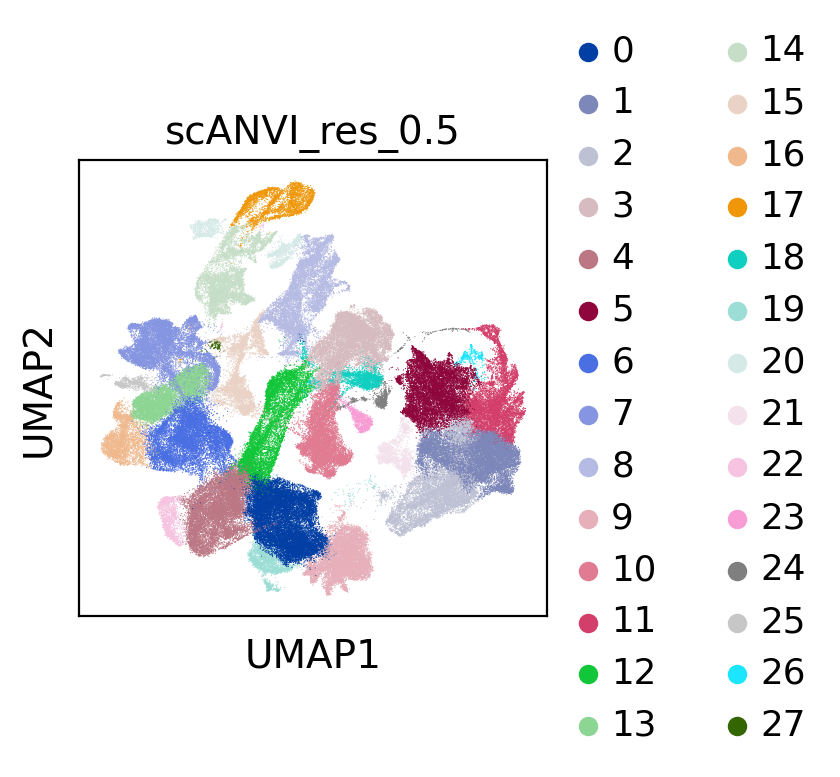

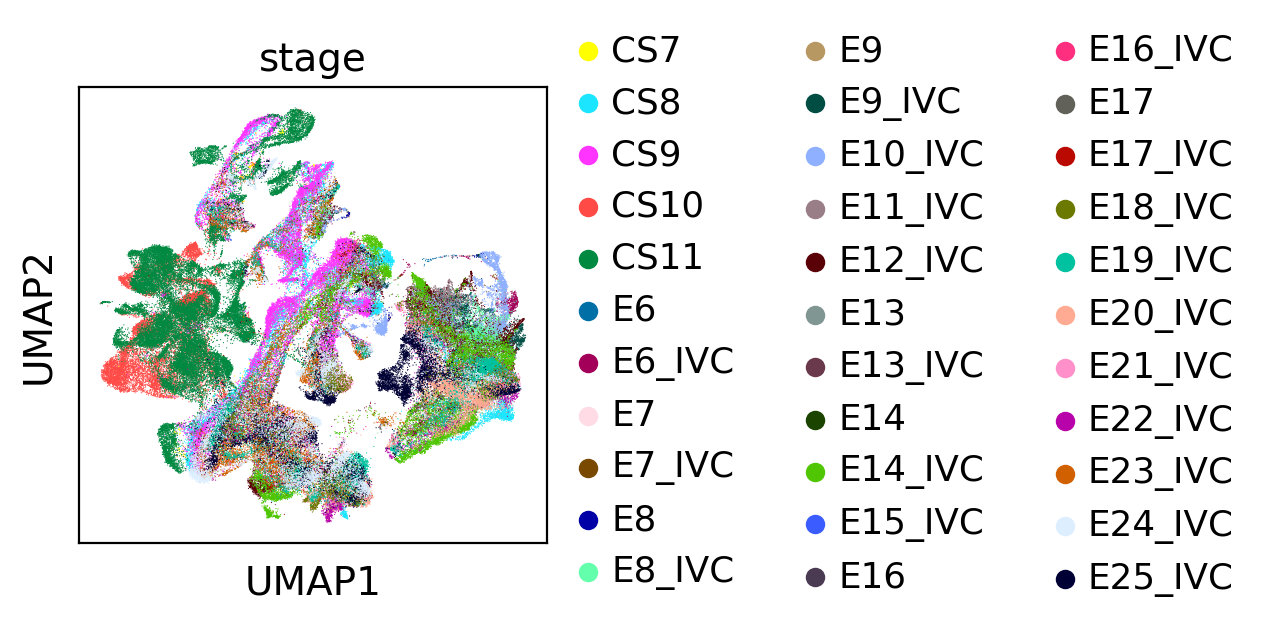

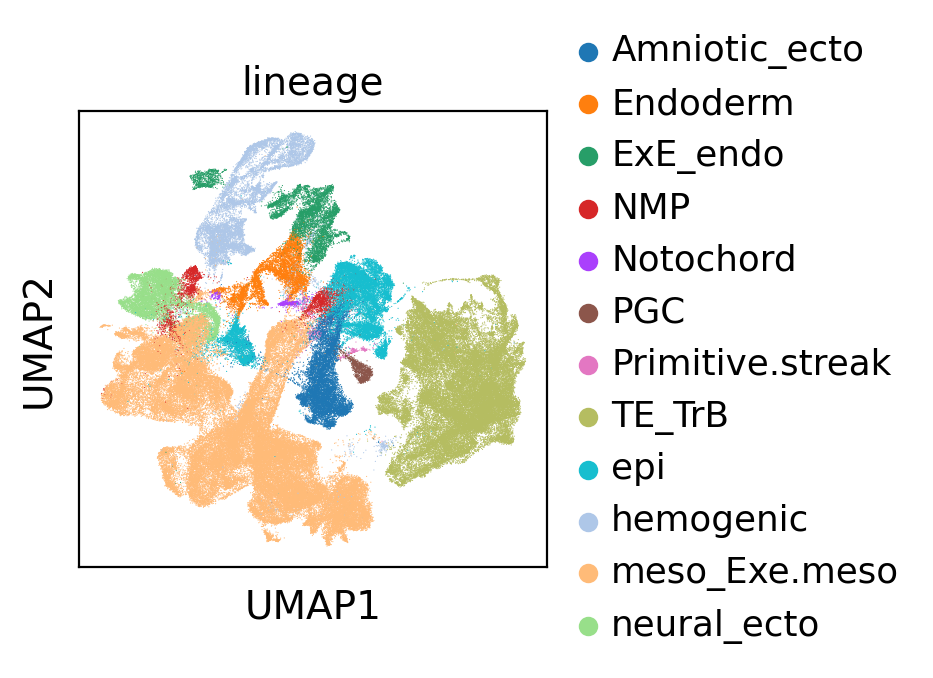

In [22]:
adata_hvg.obsm["scANVI"] = adata.obsm["scANVI"]
sc.pp.neighbors(adata, use_rep="scANVI",random_state=42)
sc.tl.leiden(adata, resolution=0.5,key_added=f"scANVI_res_0.5",random_state=42)
sc.tl.umap(adata,random_state=42)
adata.obsm['X_scANVI'] = adata.obsm['X_umap']
adata_hvg.obsm['X_scANVI'] = adata.obsm['X_scANVI']
sc.pl.umap(adata, color=['orig.ident'],save="scANVI_orig.ident.pdf")
sc.pl.umap(adata, color=['scANVI_res_0.5'],save="scANVI_res_0.5.pdf")
sc.pl.umap(adata, color=['stage'],save="scANVI_stage.pdf")
sc.pl.umap(adata, color=['lineage'],save="scANVI_lineage.pdf")

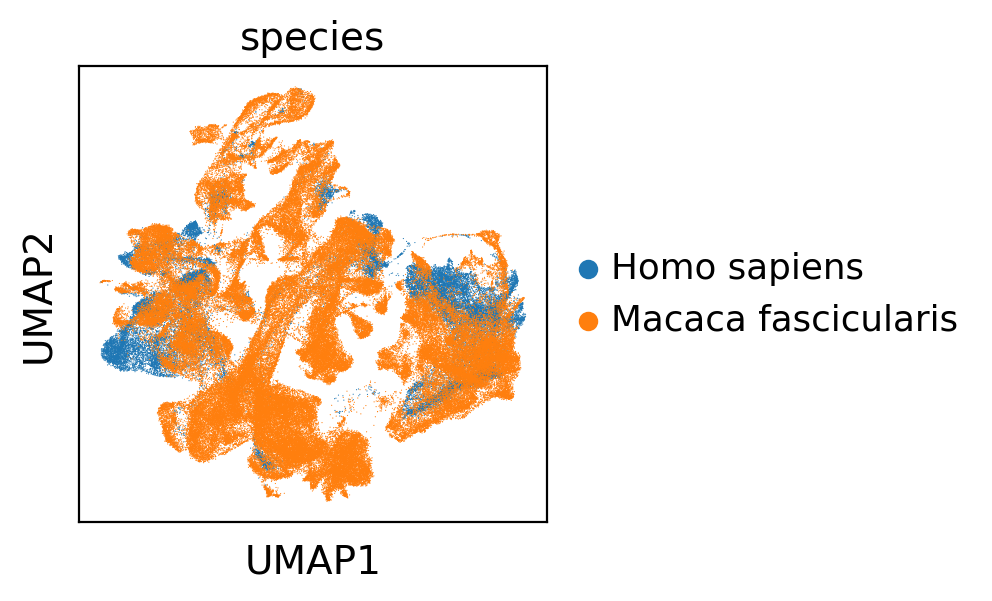

In [23]:
sc.pl.umap(adata, color=['species'],save="scANVI_species.pdf")

In [24]:
genes_to_plot = [
    "POU5F1", "NANOG",  # epiblast
    "SOX2", "TTYH1",    # neural ectoderm
    "GATA3", "TFAP2A",
    "TBXT", "CDX1", "PDGFRA", "APOA2", "FOXA2", "NANOS3","TAL1", "ISL1","DLX5","ISL1",
    "PECAM1", "HBZ", "PTPRC", "HBM",
    "GABRP", "HEY1", "COL6A1", "COL6A2"
]

# Directory to save plots
output_dir = "./gene_expression_plots"
import os
os.makedirs(output_dir, exist_ok=True)

# Loop over each gene and plot/save individually
for gene in genes_to_plot:
    fig, ax = plt.subplots(figsize=(6, 5))  # Create a new figure for each gene
    sc.pl.umap(
        adata,
        color=gene,
        use_raw=False,
        cmap=sns.cubehelix_palette(dark=0, light=.9, as_cmap=True),
        ax=ax,
        show=False,  # Prevents Scanpy from calling plt.show()
        size=15
    )
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{gene}_umap.pdf", dpi=300, bbox_inches='tight')
    plt.close()

In [25]:
adata

AnnData object with n_obs × n_vars = 176364 × 85305
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'orig_anno', 'orig_sub_anno', 'harmo.anno', 'doublet', 'doublet_score', 'scANVI_res_0.5', 'leiden_3', 'reanno', 'combined_annotation', 'unicorns', 'lineage', 'Unintegrated_res_0.5'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'leiden', 'umap', 'orig.ident_colors', 'Unintegrated_res_0.5_colors', 'stage_colors', 'lineage_colors', 'scANVI_res_0.5_colors', 'species_colors'
    obsm: 'X_pca', 'X_scANVI', 'X_umap', 'Unintegrated', 'X_Unintegrated', 'scVI', 'scANVI'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'distances', 'connectivities'

In [26]:
for col in adata.obs.select_dtypes(include='object').columns:
    print(f"\nUnique values in obs[{col!r}]:", adata.obs[col].unique())

for col in adata.var.select_dtypes(include='object').columns:
    print(f"\nUnique values in var[{col!r}]:", adata.var[col].unique())


Unique values in obs['sample']: ['Sample1' 'Sample2' 'Sample3' 'Sample4' 'Sample5' 'Sample6' 'Sample9'
 'Sample10' 'Sample11' 'Sample12' 'Sample13' 'Sample14' 'Sample15' 'NA'
 'ha_170710A' 'ha_170710B' 'ha_170710C' 'ha_170710D' 'ha_170710E'
 'ha_170710F' 'ha_170710G' 'ha_170710H' 'ha_170710I' 'ha_170710J'
 'ha_170710K' 'ha_170710L' 'ha_170714M' 'ha_170714N' 'ha_170714O'
 'ha_170714P' 'ha_170714Q' 'ha_170714R' 'ha_170714S' 'ha_170714T'
 'ha_170714U' 'ha_170714V' 'vol-d10-1-170927H' 'vol-d10-1-170927I'
 'vol-d10-14-171017J' 'vol-d10-14-171017Q' 'vol-d10-20-171017K'
 'vol-d10-20-171017L' 'vol-d10-20-171017N' 'vol-d10-30-171110B'
 'vol-d10-30-171110C' 'vol-d10-4-170927J' 'vol-d10-5-170927F'
 'vol-d10-7-170927G' 'vol-d10-8-170927E' 'vol-d12-18-171017M'
 'vol-d12-3-170927K' 'vol-d12-33-171110D' 'vol-d12-33-171110E'
 'vol-d12-33-171110L' 'vol-d12-34-171110F' 'vol-d12-34-171110G'
 'vol-d12-34-171110M' 'vol-d12-34-171110N' 'vol-d14-36-171110H'
 'vol-d14-36-171110I' 'vol-d14-36-171110J' 'vol-d1

In [27]:
adata.obs['sample'] = adata.obs['sample'].astype(str)

In [28]:
adata.raw.var.rename(columns={'_index': 'index'}, inplace=True)
adata.write_h5ad(filename="human_monkey_20250725.h5ad")